# Task 5: Transformer Backpropagation

## Objective

Implement a simple Transformer model and understand how backpropagation works.

This task demonstrates:

- Token embeddings
- Positional embeddings
- Self-attention
- Transformer layer
- Loss calculation
- Backpropagation
- Gradient calculation
- Parameter updates
- Training loss
- Prediction

The model is intentionally small and simple so that the complete process can be understood easily.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(42)

print("PyTorch version:", torch.__version__)
print("Libraries imported successfully!")

PyTorch version: 2.13.0+cpu
Libraries imported successfully!


## Step 1: Create Sample Token Data

We create a small sequence of token IDs.

The model will learn to predict the next token in the sequence.

In [2]:
vocab_size = 20
sequence_length = 6
embedding_dim = 16

input_ids = torch.tensor([
    [2, 5, 7, 4, 9, 3]
])

target_ids = torch.tensor([
    [5, 7, 4, 9, 3, 8]
])

print("Input IDs:")
print(input_ids)

print("\nTarget IDs:")
print(target_ids)

Input IDs:
tensor([[2, 5, 7, 4, 9, 3]])

Target IDs:
tensor([[5, 7, 4, 9, 3, 8]])


## Step 2: Token Embedding

Each token ID is converted into a numerical vector.

These vectors are called token embeddings.

In [3]:
embedding = nn.Embedding(
    vocab_size,
    embedding_dim
)

embedded_tokens = embedding(input_ids)

print("Input shape:", input_ids.shape)
print("Embedding shape:", embedded_tokens.shape)

Input shape: torch.Size([1, 6])
Embedding shape: torch.Size([1, 6, 16])


## Step 3: Positional Embedding

Transformers need positional information because self-attention does not automatically understand the order of tokens.

We add a positional embedding to each token embedding.

In [4]:
position_embedding = nn.Embedding(
    sequence_length,
    embedding_dim
)

positions = torch.arange(
    sequence_length
).unsqueeze(0)

positional_vectors = position_embedding(
    positions
)

transformer_input = (
    embedded_tokens
    + positional_vectors
)

print(
    "Transformer input shape:",
    transformer_input.shape
)

Transformer input shape: torch.Size([1, 6, 16])


## Step 4: Self-Attention

Self-attention allows each token to interact with other tokens in the sequence.

It uses three main components:

- Query
- Key
- Value

In [5]:
attention = nn.MultiheadAttention(
    embed_dim=embedding_dim,
    num_heads=4,
    batch_first=True
)

attention_output, attention_weights = attention(
    transformer_input,
    transformer_input,
    transformer_input
)

print(
    "Attention output shape:",
    attention_output.shape
)

print(
    "Attention weights shape:",
    attention_weights.shape
)

Attention output shape: torch.Size([1, 6, 16])
Attention weights shape: torch.Size([1, 6, 6])


## Step 5: Transformer Layer

The Transformer layer processes the attention output using self-attention and a feed-forward network.

In [6]:
transformer_layer = nn.TransformerEncoderLayer(
    d_model=embedding_dim,
    nhead=4,
    dim_feedforward=32,
    batch_first=True
)

transformer_output = transformer_layer(
    transformer_input
)

print(
    "Transformer output shape:",
    transformer_output.shape
)

Transformer output shape: torch.Size([1, 6, 16])


## Step 6: Output Layer

The Transformer output is passed through a linear layer.

The layer produces a score for every token in the vocabulary.

In [7]:
output_layer = nn.Linear(
    embedding_dim,
    vocab_size
)

logits = output_layer(
    transformer_output
)

print("Logits shape:")
print(logits.shape)

Logits shape:
torch.Size([1, 6, 20])


## Step 7: Calculate Loss

Cross-entropy loss measures how different the predicted tokens are from the target tokens.

A lower loss means the model is making better predictions.

In [8]:
loss = F.cross_entropy(
    logits.reshape(-1, vocab_size),
    target_ids.reshape(-1)
)

print(
    "Initial Loss:",
    loss.item()
)

Initial Loss: 3.093111753463745


## Step 8: Backpropagation

Backpropagation calculates gradients for the trainable parameters.

These gradients tell the optimizer how the parameters should change to reduce the loss.

In [9]:
parameters = (
    list(embedding.parameters())
    + list(position_embedding.parameters())
    + list(attention.parameters())
    + list(transformer_layer.parameters())
    + list(output_layer.parameters())
)

for parameter in parameters:
    parameter.grad = None

loss.backward()

print("Backpropagation completed successfully!")

Backpropagation completed successfully!


## Step 9: Inspect Gradients

We check the gradient values of some model parameters.

Gradients are produced during backpropagation.

In [10]:
print(
    "Embedding gradient mean:",
    embedding.weight.grad.abs().mean().item()
)

print(
    "Output layer gradient mean:",
    output_layer.weight.grad.abs().mean().item()
)

Embedding gradient mean: 0.003880048869177699
Output layer gradient mean: 0.05532199889421463


## Step 10: Update Parameters

The Adam optimizer uses the gradients calculated during backpropagation to update the model parameters.

In [11]:
optimizer = torch.optim.Adam(
    parameters,
    lr=0.01
)

optimizer.step()

print("Model parameters updated successfully!")

Model parameters updated successfully!


## Step 11: Train the Model

The training process is repeated for several epochs.

Each epoch performs:

1. Forward pass
2. Loss calculation
3. Backpropagation
4. Parameter update

In [12]:
loss_history = []

epochs = 50

for epoch in range(epochs):

    optimizer.zero_grad()

    # Token embedding
    embedded_tokens = embedding(
        input_ids
    )

    # Positional embedding
    positional_vectors = position_embedding(
        positions
    )

    # Combine embeddings
    transformer_input = (
        embedded_tokens
        + positional_vectors
    )

    # Transformer
    transformer_output = transformer_layer(
        transformer_input
    )

    # Output layer
    logits = output_layer(
        transformer_output
    )

    # Loss
    loss = F.cross_entropy(
        logits.reshape(-1, vocab_size),
        target_ids.reshape(-1)
    )

    # Backpropagation
    loss.backward()

    # Update parameters
    optimizer.step()

    loss_history.append(
        loss.item()
    )

    if (epoch + 1) % 10 == 0:

        print(
            f"Epoch {epoch + 1}: "
            f"Loss = {loss.item():.4f}"
        )

Epoch 10: Loss = 0.6734
Epoch 20: Loss = 0.1418
Epoch 30: Loss = 0.0335
Epoch 40: Loss = 0.0168
Epoch 50: Loss = 0.0108


## Step 12: Visualize Training Loss

The graph shows how the loss changes during training.

A decreasing loss indicates that the model is learning from the training data.

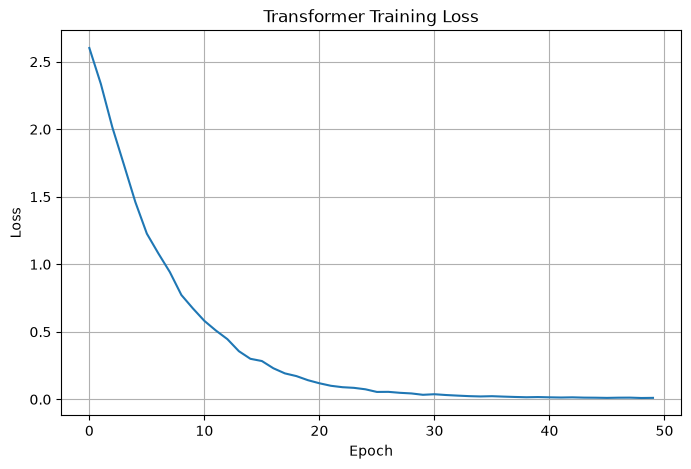

In [13]:
plt.figure(figsize=(8, 5))

plt.plot(
    loss_history
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Transformer Training Loss"
)

plt.grid(True)

plt.show()

## Step 13: Generate Predictions

The model predicts the token with the highest probability at each position.

In [14]:
predictions = torch.argmax(
    logits,
    dim=-1
)

print("Input:")
print(input_ids)

print("\nTarget:")
print(target_ids)

print("\nPredictions:")
print(predictions)

Input:
tensor([[2, 5, 7, 4, 9, 3]])

Target:
tensor([[5, 7, 4, 9, 3, 8]])

Predictions:
tensor([[5, 7, 4, 9, 3, 8]])


## Step 14: Calculate Accuracy

Accuracy measures how many predicted tokens match the target tokens.

In [15]:
accuracy = (
    predictions == target_ids
).float().mean()

print(
    "Prediction Accuracy:",
    round(
        accuracy.item() * 100,
        2
    ),
    "%"
)

Prediction Accuracy: 100.0 %


## Step 15: Results

The simplified Transformer successfully demonstrates:

- Token embedding
- Positional embedding
- Self-attention
- Transformer processing
- Loss calculation
- Backpropagation
- Gradient calculation
- Parameter updates
- Training
- Token prediction

In [16]:
print("========== TASK 5 RESULTS ==========")

print(
    "Initial Loss:",
    round(loss_history[0], 4)
)

print(
    "Final Loss:",
    round(loss_history[-1], 4)
)

print(
    "Prediction Accuracy:",
    round(
        accuracy.item() * 100,
        2
    ),
    "%"
)

print(
    "Training Epochs:",
    epochs
)

print("====================================")

========== TASK 5 RESULTS ==========
Initial Loss: 2.6016
Final Loss: 0.0108
Prediction Accuracy: 100.0 %
Training Epochs: 50


# Conclusion

A simplified Transformer model was implemented using PyTorch.

The model converts tokens into embeddings, adds positional information, processes them using self-attention and a Transformer layer, and predicts target tokens.

Cross-entropy loss was used to measure prediction error. Backpropagation calculated gradients, and the Adam optimizer updated the model parameters.

This task demonstrates the basic training process used by modern Transformer-based language models.